In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from SATpackage import kSATGenerator, SATsolver

In [11]:
filename = "results_3sat/test_run1_n10.csv"
n = 10

df_results = pd.read_csv(filename)
summary_df = df_results.groupby(['p', 'm'])[['energy_Hc', 'success_prob', 'time_sec']].agg(['mean', 'std']).reset_index()
summary_df.columns = ['_'.join(col).strip('_') for col in summary_df.columns.values]
std_cols = ['energy_Hc_std', 'success_prob_std', 'time_sec_std']
N_iterations = df_results['trial'].nunique()
summary_df[std_cols] = summary_df[std_cols] / np.sqrt(N_iterations) # std mean

# print a summary
print("Summary of the dataset:")
print(f"n qubits/variables: {n}")
print(f"p values: {summary_df['p'].unique()}")
print(f"m values: {summary_df['m'].unique()}")
print(f"Number of trials per (p, m) pair: {N_iterations}")
print("\nSummary DataFrame:")
print(summary_df.head())

Summary of the dataset:
n qubits/variables: 10
p values: [ 1  2  4  8 16]
m values: [10 20 30 40 45 50 60 70]
Number of trials per (p, m) pair: 50

Summary DataFrame:
   p   m  energy_Hc_mean  energy_Hc_std  success_prob_mean  success_prob_std  \
0  1  10        0.801526       0.060653           0.470430          0.035903   
1  1  20        1.500300       0.094565           0.268594          0.023875   
2  1  30        2.611444       0.120725           0.076621          0.011156   
3  1  40        3.447291       0.143692           0.034531          0.005763   
4  1  45        4.010306       0.163382           0.023750          0.005127   

   time_sec_mean  time_sec_std  
0       2.203594      0.122936  
1       2.389307      0.113979  
2       2.295013      0.059685  
3       2.391720      0.134939  
4       2.480071      0.093219  


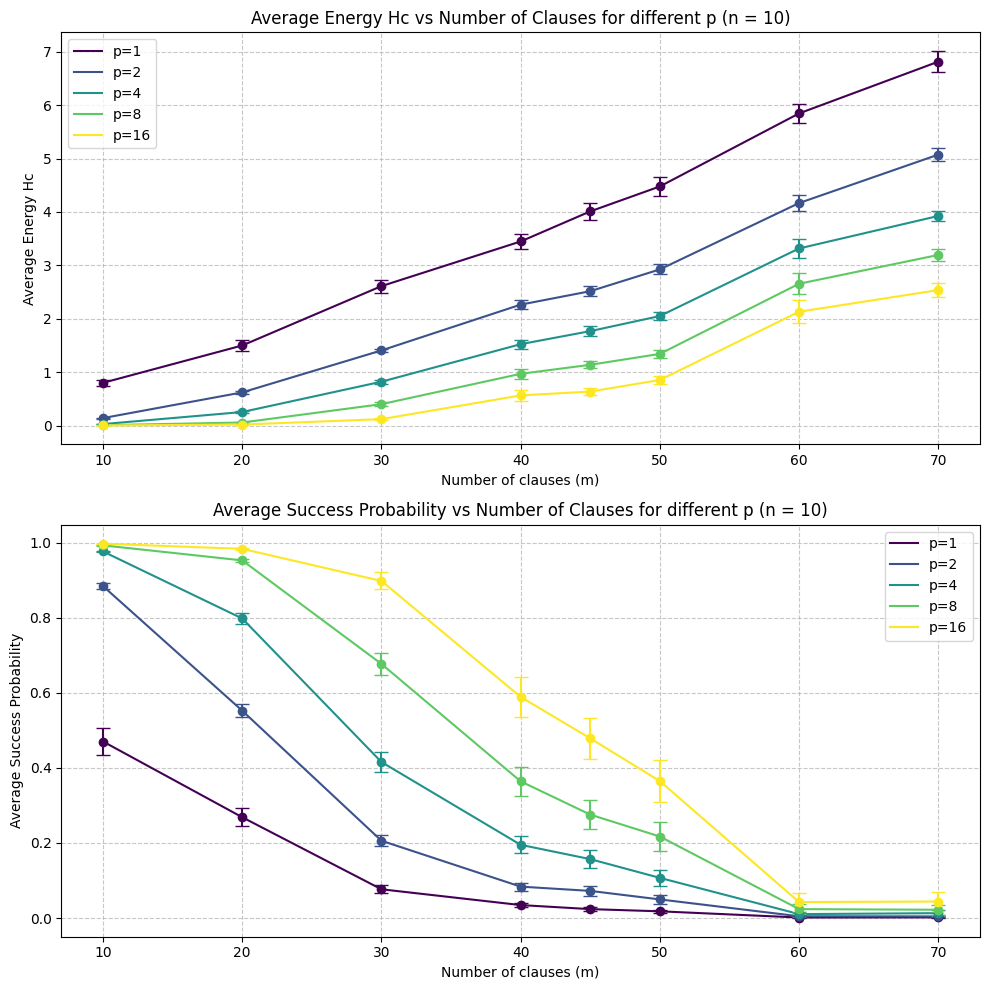

In [12]:
# Plotting the results from summary_df
# Hc energy and success probability vs m for different p values

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
p_list = summary_df['p'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(p_list)))

for idx, p in enumerate(p_list):
    subset = summary_df[summary_df['p'] == p]
    ax[0].plot(subset['m'], subset['energy_Hc_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[0].errorbar(subset['m'], subset['energy_Hc_mean'], yerr=subset['energy_Hc_std'], fmt='o', capsize=5, color=colors[idx])
    ax[1].plot(subset['m'], subset['success_prob_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[1].errorbar(subset['m'], subset['success_prob_mean'], yerr=subset['success_prob_std'], fmt='o', capsize=5, color=colors[idx])

# plot 1 (Energy)
ax[0].set_xlabel('Number of clauses (m)')
ax[0].set_ylabel('Average Energy Hc')
ax[0].set_title(f'Average Energy Hc vs Number of Clauses for different p (n = {n})')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# plot 2 (Success Probability)
ax[1].set_xlabel('Number of clauses (m)')
ax[1].set_ylabel('Average Success Probability')
ax[1].set_title(f'Average Success Probability vs Number of Clauses for different p (n = {n})')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

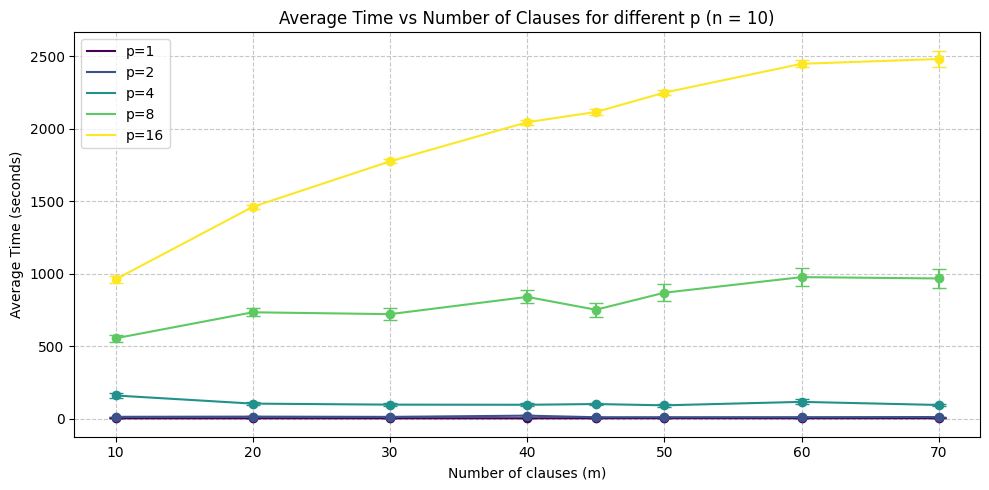

In [13]:
# time benchmark
plt.figure(figsize=(10, 5))
for idx, p in enumerate(p_list):
    subset = summary_df[summary_df['p'] == p]
    plt.plot(subset['m'], subset['time_sec_mean'], marker='', label=f'p={p}', color=colors[idx])
    plt.errorbar(subset['m'], subset['time_sec_mean'], yerr=subset['time_sec_std'], fmt='o', capsize=5, color=colors[idx])
plt.xlabel('Number of clauses (m)')
plt.ylabel('Average Time (seconds)')
plt.title(f'Average Time vs Number of Clauses for different p (n = {n})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

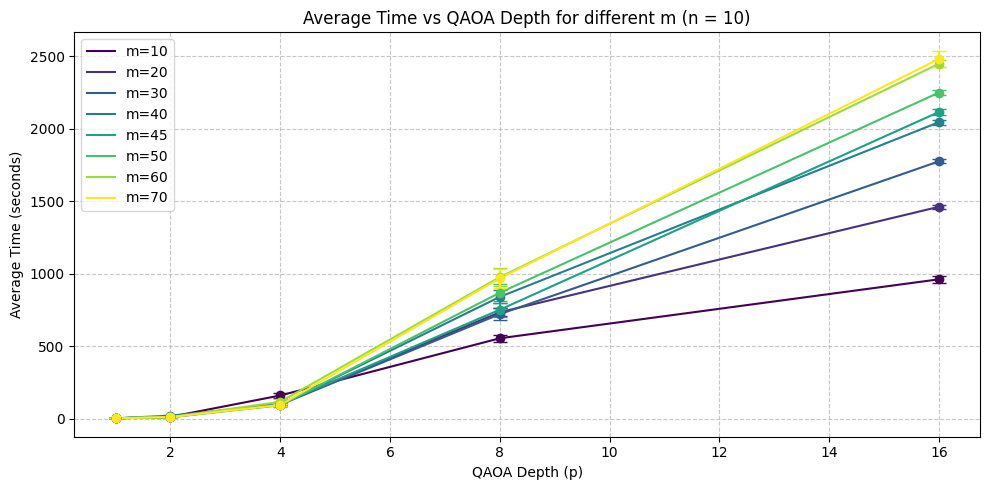

In [14]:
# time vs p for different m values
plt.figure(figsize=(10, 5))
m_list = summary_df['m'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(m_list)))
for idx, m in enumerate(m_list):
    subset = summary_df[summary_df['m'] == m]
    plt.plot(subset['p'], subset['time_sec_mean'], marker='', label=f'm={m}', color=colors[idx])
    plt.errorbar(subset['p'], subset['time_sec_mean'], yerr=subset['time_sec_std'], fmt='o', capsize=5, color=colors[idx])
plt.xlabel('QAOA Depth (p)')
plt.ylabel('Average Time (seconds)')
plt.title(f'Average Time vs QAOA Depth for different m (n = {n})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

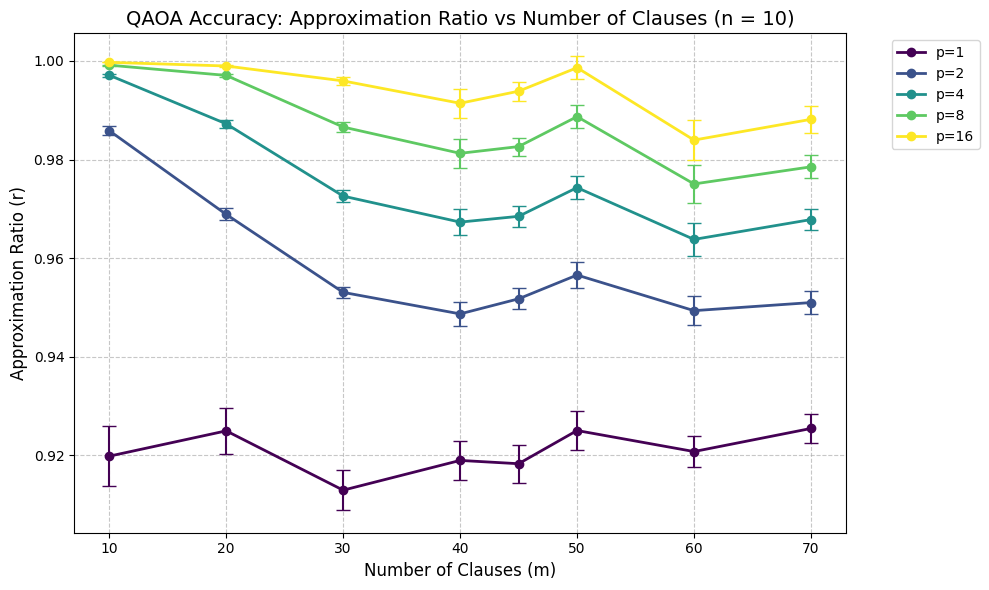

In [15]:
summary_ratio = df.groupby(['p', 'm'])[['approx_ratio']].agg(['mean', 'sem']).reset_index()
summary_ratio.columns = ['_'.join(col).strip('_') if type(col) is tuple and col[1] else col[0] for col in summary_ratio.columns.values]

plt.figure(figsize=(10, 6))
p_values = summary_ratio['p'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(p_values)))

for idx, p in enumerate(sorted(p_values)):
    subset = summary_ratio[summary_ratio['p'] == p]
    plt.plot(subset['m'], subset['approx_ratio_mean'], marker='o', linewidth=2, label=f'p={p}', color=colors[idx])
    plt.errorbar(subset['m'], subset['approx_ratio_mean'], yerr=subset['approx_ratio_sem'], fmt='none', capsize=5, color=colors[idx])

plt.xlabel('Number of Clauses (m)', fontsize=12)
plt.ylabel('Approximation Ratio (r)', fontsize=12)
plt.title(f'QAOA Accuracy: Approximation Ratio vs Number of Clauses (n = {num_vars})', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
n_list = [6, 10, 16]
alpha_range = np.linspace(0.1, 5, 20)
N_samples = int(1e5)

results = {}

generator = kSATGenerator(k=2)

for n in n_list:
    probs = []
    m_list = (alpha_range * n).astype(int)
    for m in m_list:
        count_m = 0
        for _ in range(N_samples): 
            formula = generator.generate(num_clauses=m, num_vars=n)
            count_m += 1 if SATsolver(formula) else 0
        probs.append(count_m / N_samples)
        
    results[n] = probs

In [ ]:
df = pd.DataFrame({'alpha': alpha_range})
for n in n_list:
    df[f'n={n}'] = results[n]
df.to_csv('2SAT_Phase_Transition_Results.csv', index=False)

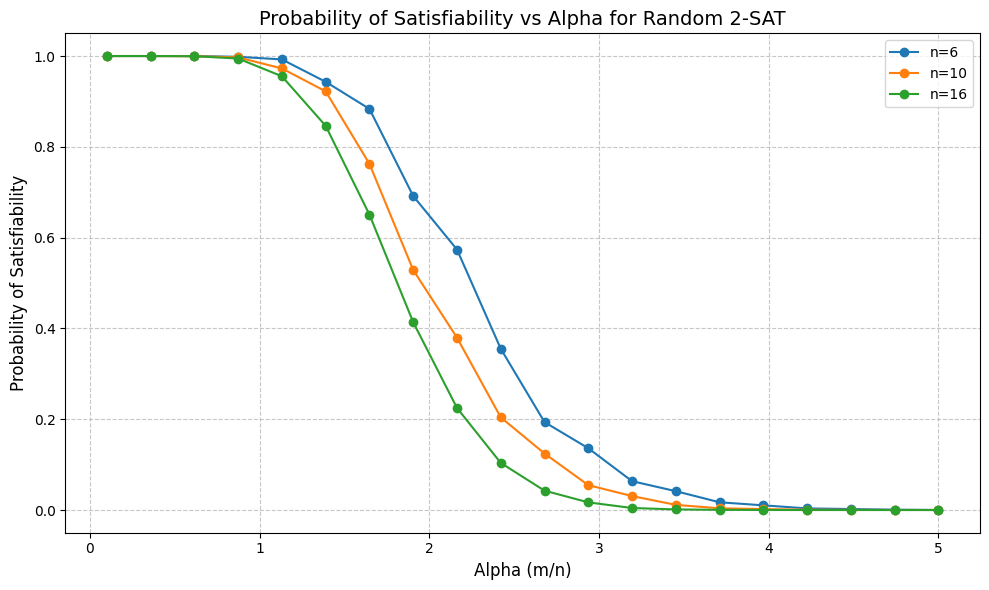

In [ ]:
# Plotting the probability of satisfiability vs alpha
plt.figure(figsize=(10, 6))
for n in n_list:
    plt.plot(alpha_range, results[n], marker='o', linestyle='-', label=f'n={n}')
plt.xlabel('Alpha (m/n)', fontsize=12)
plt.ylabel('Probability of Satisfiability', fontsize=12)
plt.title('Probability of Satisfiability vs Alpha for Random 2-SAT', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()